In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [14]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/asdasdasasdas
/kaggle/input/datasets/asdasdasasdas/garbage-classification
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/metal
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/glass
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/paper
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/trash
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/cardboard
/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification/plastic

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(

"/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification",

validation_split=0.2,

subset="training",

seed=42,

image_size=(224,224),

batch_size=32

)

val_ds = tf.keras.utils.image_dataset_from_directory(

"/kaggle/input/datasets/asdasdasasdas/garbage-classification/Garbage classification/Garbage classification",

validation_split=0.2,

subset="validation",

seed=42,

image_size=(224,224),

batch_size=32

)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [18]:
num_classes = len(train_ds.class_names)

print(train_ds.class_names)

print(num_classes)


['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
6


In [20]:
inputs = tf.keras.Input(
shape=(224,224,3)
)

x = tf.keras.layers.Rescaling(
1./255
)(inputs)

x = tf.keras.layers.Conv2D(
64,
16,
strides=16
)(x)

x = tf.keras.layers.Reshape(
(-1,64)
)(x)

x = tf.keras.layers.MultiHeadAttention(
num_heads=4,
key_dim=64
)(
x,
x
)

x = tf.keras.layers.GlobalAveragePooling1D()(x)

x = tf.keras.layers.Dense(
128,
activation='relu'
)(x)

outputs = tf.keras.layers.Dense(
num_classes,
activation='softmax'
)(x)

model = tf.keras.Model(
inputs,
outputs
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 14, 14,    │     49,216 │ rescaling_1[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 196, 64)   │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 196, 64)   │     66,368 │ reshape_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ multi_head_atten… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 6)         │        774 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,678 (487.02 KB)

 Trainable params: 124,678 (487.02 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(

optimizer='adam',

loss='sparse_categorical_crossentropy',

metrics=['accuracy']

)

In [25]:
history = model.fit(

train_ds,

validation_data=val_ds,

epochs=20

)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - accuracy: 0.6316 - loss: 1.0115 - val_accuracy: 0.5267 - val_loss: 1.2802
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - accuracy: 0.6137 - loss: 1.0072 - val_accuracy: 0.5901 - val_loss: 1.1483
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 15s 236ms/step - accuracy: 0.6647 - loss: 0.9155 - val_accuracy: 0.5842 - val_loss: 1.1628
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 241ms/step - accuracy: 0.6672 - loss: 0.9155 - val_accuracy: 0.5842 - val_loss: 1.1642
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.6523 - loss: 0.9179 - val_accuracy: 0.5782 - val_loss: 1.1121
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.6795 - loss: 0.8798 - val_accuracy: 0.5743 - val_loss: 1.1495
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.6711 - loss: 0.8744 - val_accuracy: 0.5525 - val_loss: 1.2782
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 247ms/step - accuracy: 0.6751 - loss: 0.8724 - val_accu

In [26]:
loss, accuracy = model.evaluate(val_ds)

print("Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5822 - loss: 1.1870
Accuracy: 0.5821782350540161


In [27]:
y_true = []
y_pred = []

for images, labels in val_ds:

    pred = model.predict(images)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(pred, axis=1)
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


In [28]:
from sklearn.metrics import (
precision_score,
recall_score,
f1_score
)

precision = precision_score(
y_true,
y_pred,
average='weighted'
)

recall = recall_score(
y_true,
y_pred,
average='weighted'
)

f1 = f1_score(
y_true,
y_pred,
average='weighted'
)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

Precision: 0.578045819658884
Recall: 0.5821782178217821
F1 Score: 0.5764083317318799


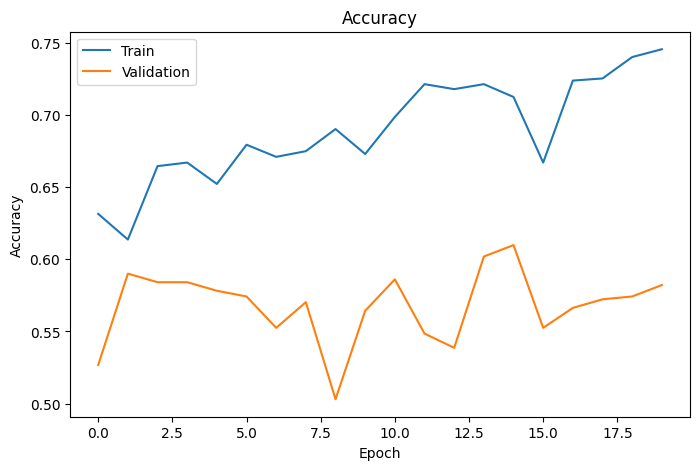

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
history.history['accuracy']
)

plt.plot(
history.history['val_accuracy']
)

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(
["Train","Validation"]
)

plt.show()